# Predicting diabetes

In the previous project we saw how we could use a decision tree to predict data sets related to classification and regression. 
However, did you know that we can improve the prediction of a tree by using a random forest?

As we have studied, a random forest is a grouping of trees generated with random portions of the data and with random criteria. 
This view would allow us to improve the effectiveness of the model when an individual tree is not sufficient.

In this project you will focus on this idea by training the dataset to improve the accuracy.

## Step 1: Loading the dataset

Load the processed dataset from the previous project.

This notebook assumes that the cleaned file is saved as `data/diabetes_clean.csv`.

## Step 2: Build a random forest

We will train a baseline random forest and then try different values of two important hyperparameters:

- `n_estimators`
- `max_depth`

Then we will compare the accuracy and plot the conclusions.

## Step 3: Save the model

Finally, we save the best model in a folder called `models`.

# Possible solution

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
df = pd.read_csv('../data/processed/diabetes_clean.csv')

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,125,33.6,0.627,50,1
1,1,85,66,29,125,26.6,0.351,31,0
2,8,183,64,29,125,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
print('Shape:', df.shape)
print()
df.info()

Shape: (768, 9)

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (614, 8)
X_test: (154, 8)
y_train: (614,)
y_test: (154,)


## Baseline random forest

In [8]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))
print('Classification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.7792207792207793
Confusion Matrix:
[[88 12]
 [22 32]]
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       100
           1       0.73      0.59      0.65        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154



## Test different hyperparameter values

In [9]:
n_estimators_list = [10, 50, 100, 200]
max_depth_list = [3, 5, 7, 10, None]

results = []

for n in n_estimators_list:
    for depth in max_depth_list:
        model = RandomForestClassifier(
            n_estimators=n,
            max_depth=depth,
            random_state=42
        )
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        results.append({
            'n_estimators': n,
            'max_depth': depth,
            'accuracy': acc
        })

results_df = pd.DataFrame(results)
results_df

,n_estimators,max_depth,accuracy
0,10,3.0,0.720779
1,10,5.0,0.694805
2,10,7.0,0.746753
3,10,10.0,0.733766
4,10,NaN,0.772727
5,50,3.0,0.740260
6,50,5.0,0.733766
7,50,7.0,0.746753
8,50,10.0,0.707792
9,50,NaN,0.746753


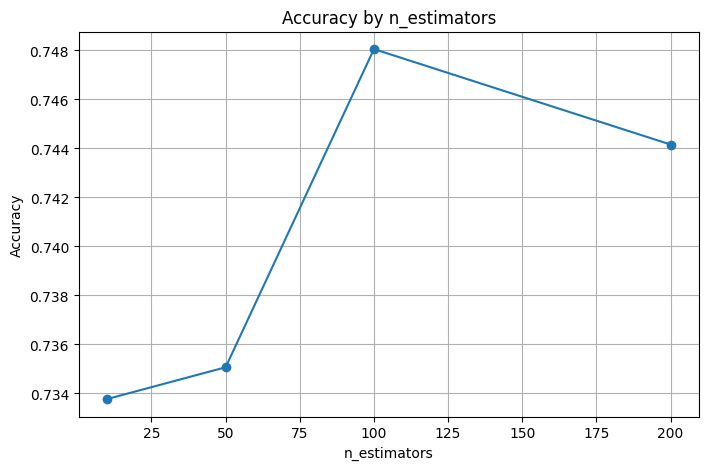

In [10]:
mean_by_estimators = results_df.groupby('n_estimators')['accuracy'].mean()

plt.figure(figsize=(8, 5))
plt.plot(mean_by_estimators.index, mean_by_estimators.values, marker='o')
plt.title('Accuracy by n_estimators')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

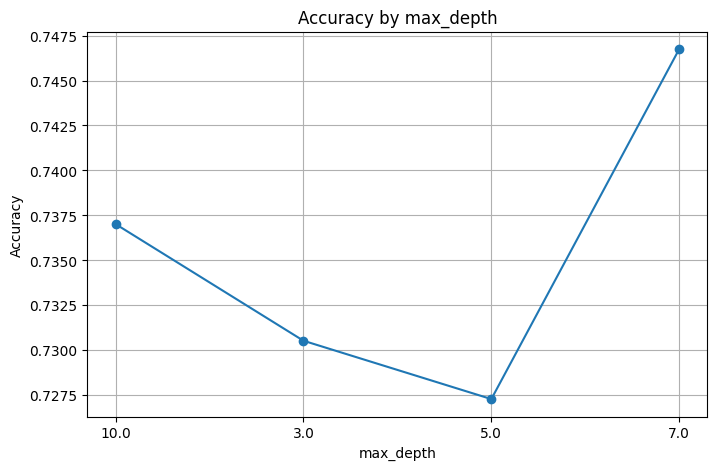

In [12]:
results_df['max_depth'] = results_df['max_depth'].astype(str)
mean_by_depth = results_df.groupby('max_depth')['accuracy'].mean()

plt.figure(figsize=(8, 5))
plt.plot(mean_by_depth.index, mean_by_depth.values, marker='o')
plt.title('Accuracy by max_depth')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

## Choose the best model

In [13]:
best_row = results_df.sort_values(by='accuracy', ascending=False).iloc[0]

best_n = best_row['n_estimators']
best_depth = best_row['max_depth']

print('Best n_estimators:', best_n)
print('Best max_depth:', best_depth)

Best n_estimators: 100
Best max_depth: nan


In [15]:
best_row = results_df.sort_values(by='accuracy', ascending=False).iloc[0]

best_n = int(best_row['n_estimators'])
best_depth = best_row['max_depth']

if pd.isna(best_depth):
    best_depth = None

best_model = RandomForestClassifier(
    n_estimators=best_n,
    max_depth=best_depth,
    random_state=42
)

best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

print('Best model accuracy:', accuracy_score(y_test, y_pred_best))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_best))
print('Classification Report:')
print(classification_report(y_test, y_pred_best))

Best model accuracy: 0.7792207792207793
Confusion Matrix:
[[88 12]
 [22 32]]
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       100
           1       0.73      0.59      0.65        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154



## Save the model

In [16]:
os.makedirs('models', exist_ok=True)
joblib.dump(best_model, 'models/random_forest_diabetes.joblib')
print('Model saved in models/random_forest_diabetes.joblib')

Model saved in models/random_forest_diabetes.joblib
